# Part 3 — μP scaling and extrapolation**Course:** CS-GY 6923 · Part 3 (~25%)Correct µP: attention scaled by `1/d_head` (not `1/√d_head`), `MuReadout`, `MuAdam`,`set_base_shapes` with matching architecture. Tiny LR sweep → transfer to all widths.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/svg_scaling_v2'
print('ready')

Mounted at /content/drive
ready


In [2]:
!pip install -q mup torch numpy matplotlib scipy tqdm seaborn

  Preparing metadata (setup.py) ... done


In [3]:
import json, math, time, random, gc, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from mup import MuReadout, MuAdam, set_base_shapes
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cuda


In [4]:
with open(f'{DRIVE}/data/meta.json') as f:
    meta = json.load(f)
VOCAB = meta['vocab_size']
PAD = meta['pad']
BOS = meta['bos']
EOS = meta['eos']
with open(f'{DRIVE}/results/lr_sweep.json') as f:
    lr_data = json.load(f)
BEST_SP_LR = lr_data['best_lr']
TINY_PARAMS = lr_data['tiny_params']
with open(f'{DRIVE}/results/sp_results.json') as f:
    sp_results = json.load(f)
print(f"best SP LR (tiny): {BEST_SP_LR:.2e}")
print("SP losses:", {k: round(v['val'], 4) for k, v in sp_results.items()})

best SP LR (tiny): 8.00e-03
SP losses: {'Tiny': 0.5834, 'Small': 0.5348, 'Medium': 0.5266, 'Large': 0.5159, 'XL': 0.5017}


In [5]:
SEQ_LEN = 512
BATCH = 64
class TokenDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.seq_len = seq_len
        self._np = np.asarray(tokens) if not isinstance(tokens, torch.Tensor) else None
        self._buf = tokens if isinstance(tokens, torch.Tensor) else None
        self.n = (len(tokens) - 1) // seq_len
    def __len__(self): return self.n
    def __getitem__(self, i):
        s = i * self.seq_len
        if self._buf is not None: chunk = self._buf[s:s+self.seq_len+1]
        else: chunk = torch.from_numpy(self._np[s:s+self.seq_len+1].copy())
        return chunk[:-1].long(), chunk[1:].long()
train_toks = np.load(f'{DRIVE}/data/train.npy', mmap_mode='r')
val_toks = np.load(f'{DRIVE}/data/val.npy', mmap_mode='r')
train_ds = TokenDataset(train_toks, SEQ_LEN)
val_ds = TokenDataset(val_toks, SEQ_LEN)
print(f"train: {len(train_toks):,} | val: {len(val_toks):,}")

CONFIGS = {
    'Tiny':   dict(d=128,  n_layers=4,  n_heads=4,  d_ff=512),
    'Small':  dict(d=192,  n_layers=6,  n_heads=6,  d_ff=768),
    'Medium': dict(d=384,  n_layers=6,  n_heads=6,  d_ff=1536),
    'Large':  dict(d=512,  n_layers=10, n_heads=8,  d_ff=2048),
    'XL':     dict(d=768,  n_layers=12, n_heads=12, d_ff=3072),
}

train: 112,654,174 | val: 1,139,210


## 3.1 µP model definition**Key µP changes from SP:**1. Attention scaled by `1/d_head` (not `1/√d_head`)2. `MuReadout` output layer (no weight tying — µP needs separate output)3. `set_base_shapes` for width-dependent LR/init multipliers4. `MuAdam` optimizer

In [6]:
_HAS_SDPA = hasattr(F, 'scaled_dot_product_attention')

class MuPAttention(nn.Module):
    """µP attention: scale by 1/d_head (not 1/sqrt(d_head))."""
    def __init__(self, d, n_heads, dropout=0.0, max_len=1024):
        super().__init__()
        assert d % n_heads == 0
        self.h = n_heads
        self.dh = d // n_heads
        # Separate Q/K/V for cleaner mup shape tracking
        self.wq = nn.Linear(d, d, bias=False)
        self.wk = nn.Linear(d, d, bias=False)
        self.wv = nn.Linear(d, d, bias=False)
        self.proj = nn.Linear(d, d, bias=False)
        self.out_drop = nn.Dropout(dropout)
        self.drop_p = dropout
        # µP: scale = 1/d_head instead of 1/sqrt(d_head)
        self.mup_scale = 1.0 / self.dh
        if not _HAS_SDPA:
            self.register_buffer('mask', torch.tril(torch.ones(max_len, max_len)).view(1,1,max_len,max_len))

    def forward(self, x):
        B, T, C = x.shape
        q = self.wq(x).view(B, T, self.h, self.dh).transpose(1, 2)
        k = self.wk(x).view(B, T, self.h, self.dh).transpose(1, 2)
        v = self.wv(x).view(B, T, self.h, self.dh).transpose(1, 2)
        if _HAS_SDPA:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                    dropout_p=self.drop_p if self.training else 0.0,
                    scale=self.mup_scale)
        else:
            att = (q @ k.transpose(-2, -1)) * self.mup_scale
            att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_drop(self.proj(y))


class MuPBlock(nn.Module):
    def __init__(self, d, n_heads, d_ff, dropout=0.0, max_len=1024):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = MuPAttention(d, n_heads, dropout, max_len)
        self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(
            nn.Linear(d, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d), nn.Dropout(dropout),
        )
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.ff(self.ln2(x))


class GPT_muP(nn.Module):
    def __init__(self, vocab, d, n_layers, n_heads, d_ff, max_len=512, dropout=0.0):
        super().__init__()
        self.d_model = d
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(max_len, d)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([MuPBlock(d, n_heads, d_ff, dropout, max_len)
                                     for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d)
        # MuReadout: µP-aware output projection (cannot weight-tie with embedding)
        self.head = MuReadout(d, vocab, bias=False, output_mult=1.0)

        self.apply(self._init)
        for b in self.blocks:
            nn.init.normal_(b.attn.proj.weight, std=0.02 / math.sqrt(2 * n_layers))
            nn.init.normal_(b.ff[-2].weight, std=0.02 / math.sqrt(2 * n_layers))

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.drop(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        for b in self.blocks: x = b(x)
        logits = self.head(self.ln(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD)
        return logits, loss

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def make_mup(d, n_layers, n_heads, d_ff):
    """Build µP model with base/delta for set_base_shapes.
    Base width = 64 (small fixed value), delta = 128."""
    base_d = max(n_heads, 64 - (64 % n_heads))  # round to n_heads
    if base_d % n_heads != 0: base_d = n_heads * (64 // n_heads + 1)
    delta_d = base_d * 2
    if delta_d % n_heads != 0: delta_d = n_heads * (delta_d // n_heads + 1)

    ff_ratio = d_ff / float(d)
    base_ff = max(4, int(round(base_d * ff_ratio)))
    delta_ff = max(4, int(round(delta_d * ff_ratio)))

    base  = GPT_muP(VOCAB, base_d,  n_layers, n_heads, base_ff,  max_len=SEQ_LEN)
    delta = GPT_muP(VOCAB, delta_d, n_layers, n_heads, delta_ff, max_len=SEQ_LEN)
    model = GPT_muP(VOCAB, d,       n_layers, n_heads, d_ff,     max_len=SEQ_LEN)
    set_base_shapes(model, base, delta=delta)
    del base, delta
    return model

# verify
print("checking µP configs:")
for name, cfg in CONFIGS.items():
    m = make_mup(**cfg)
    print(f"  {name}: {m.n_params():,} params")
    del m
gc.collect()

checking µP configs:
  Tiny: 1,905,408 params
  Small: 4,336,128 params
  Medium: 13,980,672 params
  Large: 35,960,832 params
  XL: 91,703,808 params


30

In [7]:
def cosine_lr(step, warmup, total, lr_max, lr_min=None):
    if lr_min is None: lr_min = lr_max * 0.1
    if step < warmup: return lr_max * (step + 1) / warmup
    if step >= total: return lr_min
    t = (step - warmup) / (total - warmup)
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * t))

@torch.no_grad()
def eval_loss(model, ds, n_batches=100):
    model.eval()
    loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=0)
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= n_batches: break
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16, enabled=torch.cuda.is_available()):
            _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))

def train_mup(model, train_ds, val_ds, lr, epochs=1, tag="mup"):
    model = model.to(device)
    try:
        opt = MuAdam(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    except Exception as e:
        print(f"  MuAdam failed ({e}), falling back to AdamW")
        opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)

    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
    nw = 2 if torch.cuda.is_available() else 0
    loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=nw,
                        pin_memory=torch.cuda.is_available(), drop_last=True,
                        persistent_workers=(nw > 0))
    total = len(loader) * epochs
    warmup = min(total // 10, 300)
    history = {'train': [], 'val': [], 'val_steps': [], 'steps': []}
    step = 0
    t0 = time.time()
    running = 0.0
    n_running = 0
    diverged = False
    print(f"  {tag}: {model.n_params():,} params | lr={lr:.1e} (µP)")
    model.train()
    for _ in range(epochs):
        for x, y in loader:
            cur_lr = cosine_lr(step, warmup, total, lr)
            for g in opt.param_groups: g['lr'] = cur_lr
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16, enabled=torch.cuda.is_available()):
                _, loss = model(x, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)
            step += 1
            running += loss.item()
            n_running += 1
            if loss.item() > 20 or math.isnan(loss.item()):
                print(f"  diverged at step {step}!")
                diverged = True
                break
            if step % 200 == 0 and n_running > 0:
                history['train'].append(running / n_running)
                history['steps'].append(step)
                running = 0.0
                n_running = 0
            if step % 500 == 0:
                vl = eval_loss(model, val_ds)
                history['val'].append(vl)
                history['val_steps'].append(step)
                tl = history['train'][-1] if history['train'] else 0
                print(f"    step {step}/{total} | train={tl:.4f} val={vl:.4f} | {time.time()-t0:.0f}s")
                model.train()
        if diverged: break
    final_val = eval_loss(model, val_ds) if not diverged else float('inf')
    elapsed = time.time() - t0
    gpu_gb = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0
    print(f"  done: val={final_val:.4f} | {elapsed:.0f}s | {gpu_gb:.1f}GB GPU")
    return {'val': final_val, 'history': history, 'time': elapsed, 'gpu_gb': gpu_gb,
            'tps': (step * BATCH * SEQ_LEN) / max(elapsed, 1e-9),
            'n_params': model.n_params(), 'diverged': diverged}

## 3.2 µP LR sweep on Tiny

In [8]:
mup_lrs = [3e-4, 6e-4, 1e-3, 2e-3, 3e-3, 5e-3, 8e-3]
mup_sweep = []
print("=== µP LR sweep on Tiny ===\n")
for lr in mup_lrs:
    torch.cuda.reset_peak_memory_stats()
    m = make_mup(**CONFIGS['Tiny'])
    r = train_mup(m, train_ds, val_ds, lr=lr, tag=f"mup_tiny_{lr:.0e}")
    mup_sweep.append({'lr': lr, 'val': r['val']})
    print(f"  lr={lr:.0e} -> val={r['val']:.4f}")
    del m
    torch.cuda.empty_cache()
    gc.collect()

BEST_MUP_LR = min(mup_sweep, key=lambda x: x['val'])['lr']
print(f"\nbest µP LR: {BEST_MUP_LR:.2e}")
with open(f'{DRIVE}/results/mup_lr_sweep.json', 'w') as f:
    json.dump({'results': mup_sweep, 'best_lr': BEST_MUP_LR}, f, indent=2)

=== µP LR sweep on Tiny ===

  mup_tiny_3e-04: 1,905,408 params | lr=3.0e-04 (µP)
    step 500/3437 | train=5.6930 val=3.9869 | 24s
    step 1000/3437 | train=3.9792 val=4.0354 | 32s
    step 1500/3437 | train=4.2193 val=4.3265 | 40s
    step 2000/3437 | train=4.5619 val=4.6034 | 48s
    step 2500/3437 | train=4.7595 val=4.8515 | 57s
    step 3000/3437 | train=4.9849 val=5.0215 | 65s
  done: val=5.1510 | 72s | 2.4GB GPU
  lr=3e-04 -> val=5.1510
  mup_tiny_6e-04: 1,905,408 params | lr=6.0e-04 (µP)
    step 500/3437 | train=4.5905 val=4.0781 | 9s
    step 1000/3437 | train=4.5149 val=4.6432 | 17s
    step 1500/3437 | train=4.8549 val=5.0312 | 25s
    step 2000/3437 | train=4.4785 val=4.2651 | 33s
    step 2500/3437 | train=3.8001 val=3.6190 | 42s
    step 3000/3437 | train=3.4380 val=3.4110 | 50s
  done: val=3.3236 | 57s | 2.4GB GPU
  lr=6e-04 -> val=3.3236
  mup_tiny_1e-03: 1,905,408 params | lr=1.0e-03 (µP)
    step 500/3437 | train=4.2663 val=4.4221 | 9s
    step 1000/3437 | train=5.0

## 3.3 Train all µP models

In [9]:
mup_results = {}
print(f"=== training all µP models, lr={BEST_MUP_LR:.2e} ===\n")
for name, cfg in CONFIGS.items():
    torch.cuda.reset_peak_memory_stats()
    m = make_mup(**cfg)
    r = train_mup(m, train_ds, val_ds, lr=BEST_MUP_LR, tag=f"muP_{name}")
    if r['diverged'] or r['val'] > 10:
        print(f"  retrying {name} with lr={BEST_MUP_LR/2:.2e}")
        del m
        torch.cuda.empty_cache()
        gc.collect()
        m = make_mup(**cfg)
        r = train_mup(m, train_ds, val_ds, lr=BEST_MUP_LR/2, tag=f"muP_{name}_retry")
    mup_results[name] = {
        'val': r['val'], 'n_params': r['n_params'], 'history': r['history'],
        'time': r['time'], 'gpu_gb': r['gpu_gb'], 'tps': r['tps'], 'diverged': r['diverged'],
    }
    torch.save(m.state_dict(), f'{DRIVE}/checkpoints/mup_{name}.pt')
    del m
    torch.cuda.empty_cache()
    gc.collect()

print("\n=== SP vs µP ===")
print(f"{'model':<8} {'SP val':>9} {'µP val':>9} {'diff':>9}")
print("-" * 40)
for name in CONFIGS:
    sv = sp_results[name]['val']
    mv = mup_results[name]['val']
    print(f"{name:<8} {sv:>9.4f} {mv:>9.4f} {mv-sv:>+9.4f}")

with open(f'{DRIVE}/results/mup_results.json', 'w') as f:
    json.dump(mup_results, f, indent=2, default=str)

=== training all µP models, lr=8.00e-03 ===

  muP_Tiny: 1,905,408 params | lr=8.0e-03 (µP)
    step 500/3437 | train=4.4777 val=3.4063 | 8s
    step 1000/3437 | train=3.3372 val=3.3853 | 17s
    step 1500/3437 | train=3.3337 val=3.2179 | 25s
    step 2000/3437 | train=2.8930 val=2.8048 | 34s
    step 2500/3437 | train=2.6128 val=2.4935 | 42s
    step 3000/3437 | train=2.4624 val=2.4558 | 51s
  done: val=2.4609 | 58s | 2.4GB GPU
  muP_Small: 4,336,128 params | lr=8.0e-03 (µP)
    step 500/3437 | train=5.7122 val=4.2751 | 13s
    step 1000/3437 | train=4.0587 val=4.0291 | 25s
    step 1500/3437 | train=3.9741 val=3.8237 | 38s
    step 2000/3437 | train=3.5146 val=3.4279 | 51s
    step 2500/3437 | train=3.2375 val=3.2024 | 63s
    step 3000/3437 | train=2.8721 val=2.8487 | 76s
  done: val=2.7032 | 87s | 3.2GB GPU
  muP_Medium: 13,980,672 params | lr=8.0e-03 (µP)
    step 500/3437 | train=6.3357 val=4.2188 | 19s
    step 1000/3437 | train=3.9943 val=3.9964 | 37s
    step 1500/3437 | train

## 3.4 Comparison plot and power law fits

SP (from Part 2): α=0.8107, R²=0.9559
µP: α=2.1992, R²=-0.0000


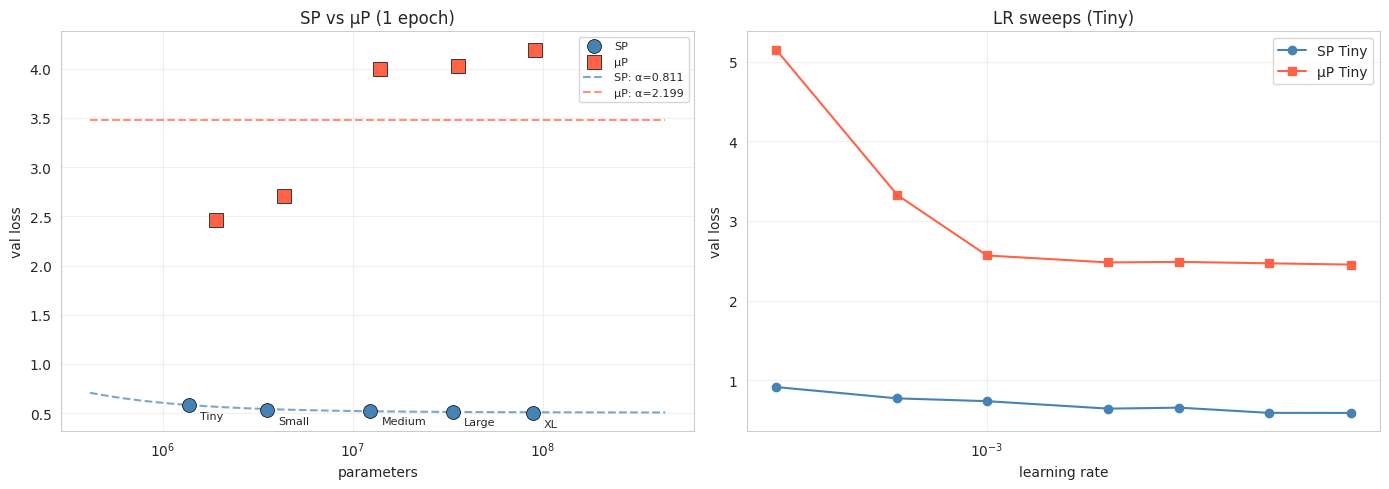

In [10]:
def power_law(N, a, alpha, c):
    return a * np.power(N, -alpha) + c
def fit_pl(params, losses):
    try:
        popt, _ = curve_fit(power_law, params, losses,
                            p0=[10.0, 0.1, min(losses)*0.9],
                            bounds=([0,0.001,0],[1e6,5,max(losses)]), maxfev=10000)
        return popt
    except: return None
def r2_of(popt, p, l):
    if popt is None: return None
    pred = power_law(p, *popt)
    return 1.0 - np.sum((l-pred)**2) / max(np.sum((l-np.mean(l))**2), 1e-12)
def _pc(d, n):
    x = d[n]
    return int(x.get('n_params', x.get('params', 0)))

sp_params = np.array([_pc(sp_results, n) for n in CONFIGS])
sp_losses = np.array([sp_results[n]['val'] for n in CONFIGS])
mup_params = np.array([_pc(mup_results, n) for n in CONFIGS])
mup_losses = np.array([mup_results[n]['val'] for n in CONFIGS])

# Load canonical SP fit from Part 2
with open(f'{DRIVE}/results/sp_fit.json') as f:
    sp_canon = json.load(f)
sp_popt = np.array([sp_canon['a'], sp_canon['alpha'], sp_canon['c']])
sp_r2 = float(sp_canon['r2'])
print(f"SP (from Part 2): α={sp_popt[1]:.4f}, R²={sp_r2:.4f}")

mup_popt = fit_pl(mup_params, mup_losses)
mup_r2 = r2_of(mup_popt, mup_params, mup_losses) if mup_popt is not None else -1
if mup_popt is not None:
    print(f"µP: α={mup_popt[1]:.4f}, R²={mup_r2:.4f}")
    with open(f'{DRIVE}/results/mup_fit.json', 'w') as f:
        json.dump({'a': float(mup_popt[0]), 'alpha': float(mup_popt[1]),
                   'c': float(mup_popt[2]), 'r2': float(mup_r2)}, f, indent=2)
else:
    print("µP fit failed")
    with open(f'{DRIVE}/results/mup_fit.json', 'w') as f:
        json.dump({'a':0,'alpha':0,'c':0,'r2':-1,'note':'fit failed'}, f, indent=2)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
xf = np.logspace(np.log10(sp_params.min()*0.3), np.log10(sp_params.max()*5), 200)
ax1.scatter(sp_params, sp_losses, s=100, c='steelblue', zorder=5, edgecolors='k', lw=0.5, label='SP')
ax1.scatter(mup_params, mup_losses, s=100, c='tomato', marker='s', zorder=5, edgecolors='k', lw=0.5, label='µP')
ax1.plot(xf, power_law(xf, *sp_popt), '--', color='steelblue', alpha=0.7, label=f"SP: α={sp_popt[1]:.3f}")
if mup_popt is not None:
    ax1.plot(xf, power_law(xf, *mup_popt), '--', color='tomato', alpha=0.7, label=f"µP: α={mup_popt[1]:.3f}")
for n, p, ls, lm in zip(CONFIGS.keys(), sp_params, sp_losses, mup_losses):
    ax1.annotate(n, (p, min(ls, lm)), textcoords='offset points', xytext=(8, -10), fontsize=8)
ax1.set_xscale('log')
ax1.set_xlabel('parameters')
ax1.set_ylabel('val loss')
ax1.set_title('SP vs µP (1 epoch)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

with open(f'{DRIVE}/results/lr_sweep.json') as f: sp_lr_data = json.load(f)
ax2.semilogx([r['lr'] for r in sp_lr_data['results']], [r['val'] for r in sp_lr_data['results']],
             'o-', color='steelblue', label='SP Tiny')
ax2.semilogx([r['lr'] for r in mup_sweep], [r['val'] for r in mup_sweep],
             's-', color='tomato', label='µP Tiny')
ax2.set_xlabel('learning rate')
ax2.set_ylabel('val loss')
ax2.set_title('LR sweeps (Tiny)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/scaling_comparison.png', dpi=150)
plt.show()

## 3.5 Extrapolation to 10× larger model

In [11]:
xl_params = _pc(sp_results, 'XL')
target_params = xl_params * 10
print(f"XL: {xl_params:,} params")
print(f"10× target: {target_params:,} params\n")

# Use best fit (higher R²) for bootstrap
use_mup = (mup_r2 is not None and mup_r2 > sp_r2)
if use_mup:
    best_p, best_l, label = mup_params, mup_losses, 'µP'
else:
    best_p, best_l, label = sp_params, sp_losses, 'SP'
print(f"→ bootstrap uses {label} (SP R²={sp_r2:.4f}, µP R²={mup_r2:.4f})")

boots = []
for _ in range(2000):
    idx = np.random.choice(len(best_p), len(best_p), replace=True)
    popt = fit_pl(best_p[idx], best_l[idx])
    if popt is not None:
        boots.append(power_law(target_params, *popt))

if boots:
    lo, hi = np.percentile(boots, [2.5, 97.5])
    pred = float(np.mean(boots))
    print(f"\n{label} bootstrap (n=2000): predicted={pred:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}]")
    with open(f'{DRIVE}/results/extrapolation.json', 'w') as f:
        json.dump({'target_params': int(target_params), 'predicted': pred,
                   'ci_95': [float(lo), float(hi)], 'chosen_for_bootstrap': label,
                   'sp_r2': sp_r2, 'mup_r2': float(mup_r2),
                   'sp_alpha': float(sp_popt[1]),
                   'mup_alpha': float(mup_popt[1]) if mup_popt is not None else 0}, f, indent=2)
else:
    print("bootstrap failed — all fits returned None")

XL: 88,558,080 params
10× target: 885,580,800 params

→ bootstrap uses SP (SP R²=0.9559, µP R²=-0.0000)

SP bootstrap (n=2000): predicted=0.4947, 95% CI=[0.4745, 0.5187]


## Done with Part 3Saved: `mup_lr_sweep.json`, `mup_results.json`, `mup_fit.json`, `extrapolation.json`